In [13]:
# ============================================================
# Kaggle Notebook: Satellite Image Classification
# Models: Custom CNN, MobileNetV2, VGG16, EfficientNetB0
# Features:
# - Data augmentation
# - Class balancing
# - Training (20 epochs)
# - Accuracy/Loss graphs
# - Classification report
# - Confusion matrix
# - Save all models
# - Prediction function for new image path
# Dataset path: /kaggle/input/satelite-images/ISatelitales
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, VGG16, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# =====================
# CONFIGURATION


In [14]:
# =====================
DATASET_PATH = "/kaggle/input/satelite-images/ISatelitales"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
OUTPUT_DIR = "/kaggle/working/models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =====================
# DATA GENERATORS
# =====================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes
CLASS_NAMES = list(train_gen.class_indices.keys())

print("Classes:", CLASS_NAMES)

# =====================


Found 25200 images belonging to 45 classes.
Found 6300 images belonging to 45 classes.
Classes: ['airplane', 'airport', 'baseball_diamond', 'basketball_court', 'beach', 'bridge', 'chaparral', 'church', 'circular_farmland', 'cloud', 'commercial_area', 'dense_residential', 'desert', 'forest', 'freeway', 'golf_course', 'ground_track_field', 'harbor', 'industrial_area', 'intersection', 'island', 'lake', 'meadow', 'medium_residential', 'mobile_home_park', 'mountain', 'overpass', 'palace', 'parking_lot', 'railway', 'railway_station', 'rectangular_farmland', 'river', 'roundabout', 'runway', 'sea_ice', 'ship', 'snowberg', 'sparse_residential', 'stadium', 'storage_tank', 'tennis_court', 'terrace', 'thermal_power_station', 'wetland']


In [15]:
# CLASS BALANCING
# =====================
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# =====================
# MODEL BUILDERS
# =====================



Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0), 11: np.float64(1.0), 12: np.float64(1.0), 13: np.float64(1.0), 14: np.float64(1.0), 15: np.float64(1.0), 16: np.float64(1.0), 17: np.float64(1.0), 18: np.float64(1.0), 19: np.float64(1.0), 20: np.float64(1.0), 21: np.float64(1.0), 22: np.float64(1.0), 23: np.float64(1.0), 24: np.float64(1.0), 25: np.float64(1.0), 26: np.float64(1.0), 27: np.float64(1.0), 28: np.float64(1.0), 29: np.float64(1.0), 30: np.float64(1.0), 31: np.float64(1.0), 32: np.float64(1.0), 33: np.float64(1.0), 34: np.float64(1.0), 35: np.float64(1.0), 36: np.float64(1.0), 37: np.float64(1.0), 38: np.float64(1.0), 39: np.float64(1.0), 40: np.float64(1.0), 41: np.float64(1.0), 42: np.float64(1.0), 43: np.float64(1.0), 44: np.float64(1.0)}


In [16]:
def build_custom_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model


def build_transfer_model(base_model):
    base_model.trainable = False
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model




In [17]:
# =====================
# TRAINING FUNCTION
# =====================

def train_and_evaluate(model, name):
    print(f"\n===== Training {name} =====")

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )

    # Save model
    model_path = os.path.join(OUTPUT_DIR, f"{name}.h5")
    model.save(model_path)
    print(f"Model saved at {model_path}")

    # Plot accuracy & loss
    plot_history(history, name)

    # Evaluation
    evaluate_model(model, name)

    return model



In [18]:
# =====================
# PLOTTING
# =====================

def plot_history(history, name):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f"{name} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{name} Loss")
    plt.legend()

    plt.show()




===== Training custom_cnn =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 453s 570ms/step - accuracy: 0.0988 - loss: 3.4714 - val_accuracy: 0.3000 - val_loss: 2.5205
Epoch 2/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 289s 366ms/step - accuracy: 0.2784 - loss: 2.5420 - val_accuracy: 0.3963 - val_loss: 2.1059
Epoch 3/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 290s 368ms/step - accuracy: 0.3544 - loss: 2.2459 - val_accuracy: 0.4760 - val_loss: 1.8432
Epoch 4/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 287s 364ms/step - accuracy: 0.4033 - loss: 2.0586 - val_accuracy: 0.4911 - val_loss: 1.8011
Epoch 5/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 288s 365ms/step - accuracy: 0.4377 - loss: 1.9345 - val_accuracy: 0.5219 - val_loss: 1.6752
Epoch 6/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 286s 363ms/step - accuracy: 0.4645 - loss: 1.8575 - val_accuracy: 0.5432 - val_loss: 1.5468
Epoch 7/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 291s 369ms/step - accuracy: 0.4887 - loss: 1.7654 - val_accuracy: 0.5756 - val_loss: 1.4567
Epoch 8/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 293s 372ms/step - accuracy: 0.5059 -

Model saved at /kaggle/working/models/custom_cnn.h5


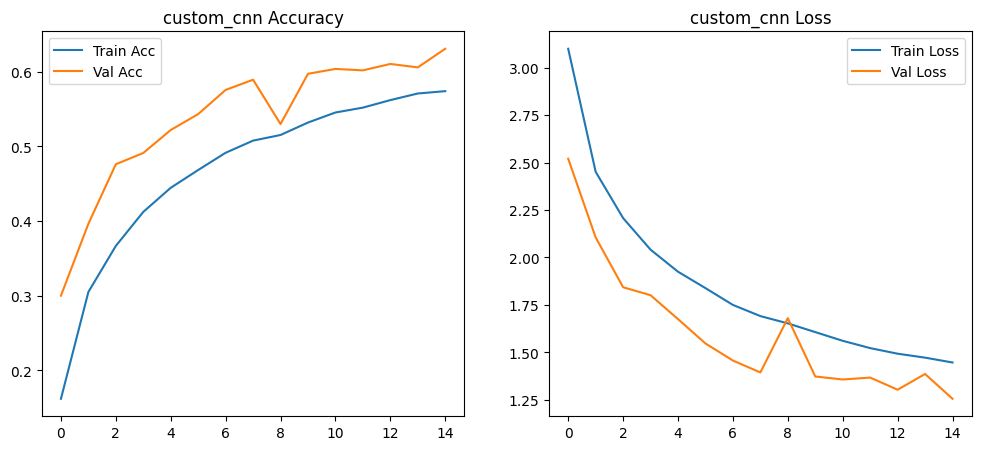

197/197 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step

Classification Report for custom_cnn
                       precision    recall  f1-score   support

             airplane       0.65      0.79      0.71       140
              airport       0.69      0.26      0.38       140
     baseball_diamond       0.57      0.62      0.60       140
     basketball_court       0.49      0.49      0.49       140
                beach       0.89      0.54      0.68       140
               bridge       0.79      0.78      0.78       140
            chaparral       0.80      0.99      0.88       140
               church       0.44      0.63      0.52       140
    circular_farmland       0.71      0.68      0.70       140
                cloud       0.83      0.94      0.88       140
      commercial_area       0.45      0.55      0.50       140
    dense_residential       0.54      0.64      0.58       140
               desert       0.91      0.84      0.88       140
               forest       0.79    

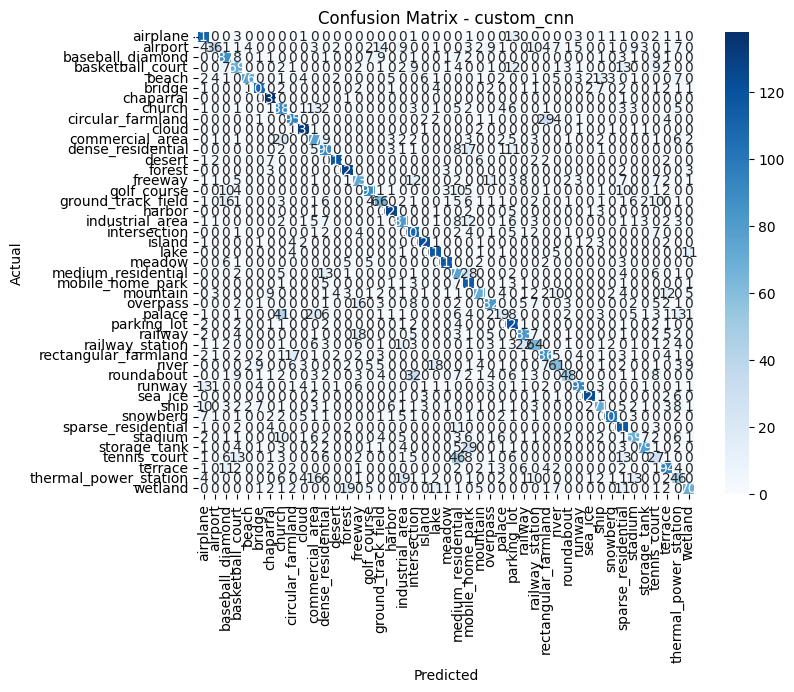

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

===== Training mobilenetv2 =====
Epoch 1/15


2026-01-16 05:40:58.040222: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 05:40:58.177848: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


724/788 ━━━━━━━━━━━━━━━━━━━━ 22s 346ms/step - accuracy: 0.3930 - loss: 2.2760

2026-01-16 05:45:18.316382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 05:45:18.454045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.4034 - loss: 2.2283

2026-01-16 05:46:08.789891: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 05:46:08.927220: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


788/788 ━━━━━━━━━━━━━━━━━━━━ 327s 395ms/step - accuracy: 0.4036 - loss: 2.2276 - val_accuracy: 0.7544 - val_loss: 0.8191
Epoch 2/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 288s 365ms/step - accuracy: 0.6554 - loss: 1.1542 - val_accuracy: 0.7846 - val_loss: 0.7097
Epoch 3/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 281s 357ms/step - accuracy: 0.7028 - loss: 1.0059 - val_accuracy: 0.7863 - val_loss: 0.6834
Epoch 4/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 287s 365ms/step - accuracy: 0.7155 - loss: 0.9402 - val_accuracy: 0.7897 - val_loss: 0.6872
Epoch 5/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 291s 369ms/step - accuracy: 0.7221 - loss: 0.9216 - val_accuracy: 0.7976 - val_loss: 0.6513
Epoch 6/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 288s 366ms/step - accuracy: 0.7308 - loss: 0.8895 - val_accuracy: 0.8090 - val_loss: 0.6293
Epoch 7/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 293s 372ms/step - accuracy: 0.7278 - loss: 0.8801 - val_accuracy: 0.8022 - val_loss: 0.6231
Epoch 8/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 295s 374ms/step - accuracy: 0.7421 - loss: 0.85

Model saved at /kaggle/working/models/mobilenetv2.h5


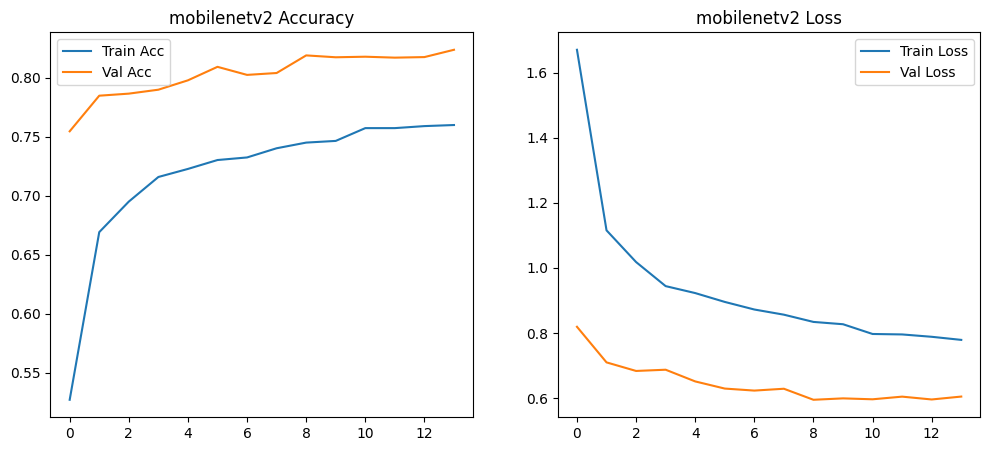

197/197 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step

Classification Report for mobilenetv2
                       precision    recall  f1-score   support

             airplane       0.94      0.82      0.88       140
              airport       0.79      0.74      0.77       140
     baseball_diamond       0.92      0.70      0.80       140
     basketball_court       0.63      0.72      0.67       140
                beach       0.89      0.78      0.83       140
               bridge       0.84      0.91      0.87       140
            chaparral       0.96      0.96      0.96       140
               church       0.54      0.54      0.54       140
    circular_farmland       0.97      0.96      0.97       140
                cloud       0.94      0.98      0.96       140
      commercial_area       0.68      0.63      0.65       140
    dense_residential       0.71      0.82      0.76       140
               desert       0.96      0.76      0.85       140
               forest       0.94   

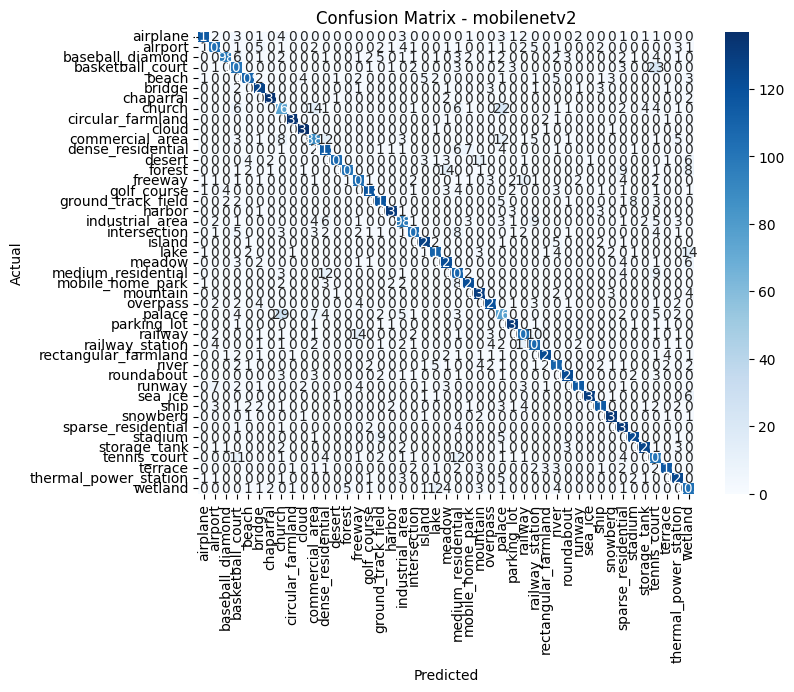

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

===== Training vgg16 =====
Epoch 1/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 367s 445ms/step - accuracy: 0.2084 - loss: 3.0213 - val_accuracy: 0.5544 - val_loss: 1.6636
Epoch 2/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 331s 419ms/step - accuracy: 0.4689 - loss: 1.8541 - val_accuracy: 0.5900 - val_loss: 1.4189
Epoch 3/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 326s 413ms/step - accuracy: 0.5372 - loss: 1.6098 - val_accuracy: 0.6478 - val_loss: 1.2526
Epoch 4/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 321s 407ms/step - accuracy: 0.5660 - loss: 1.5007 - val_accuracy: 0.6556 - val_loss: 1.1757
Epoch 5/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 324s 411ms/step - accuracy: 0.5870 - loss: 1.4133 - val_accuracy: 0.6513 - val_loss: 1.1691
Epoch 6/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 330s 418ms/step - accuracy: 0.5979 - loss: 1.3756 - val_accuracy: 0.6806 - val_loss: 1.0776
Epoch 7/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 331s 420ms/step - accuracy: 0.6090 - loss: 1.3220 - val_accuracy: 0.6841 - val_loss: 1.05

Model saved at /kaggle/working/models/vgg16.h5


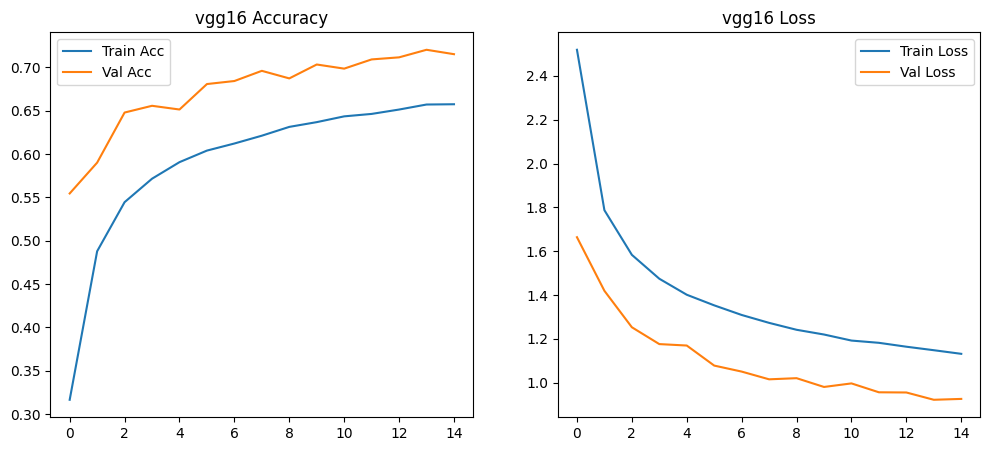

197/197 ━━━━━━━━━━━━━━━━━━━━ 36s 178ms/step

Classification Report for vgg16
                       precision    recall  f1-score   support

             airplane       0.94      0.85      0.89       140
              airport       0.71      0.65      0.68       140
     baseball_diamond       0.72      0.63      0.67       140
     basketball_court       0.58      0.53      0.55       140
                beach       0.78      0.67      0.72       140
               bridge       0.75      0.84      0.79       140
            chaparral       0.95      0.99      0.97       140
               church       0.49      0.47      0.48       140
    circular_farmland       0.96      0.89      0.92       140
                cloud       0.87      0.89      0.88       140
      commercial_area       0.47      0.54      0.50       140
    dense_residential       0.52      0.89      0.66       140
               desert       0.83      0.73      0.78       140
               forest       0.78      0.

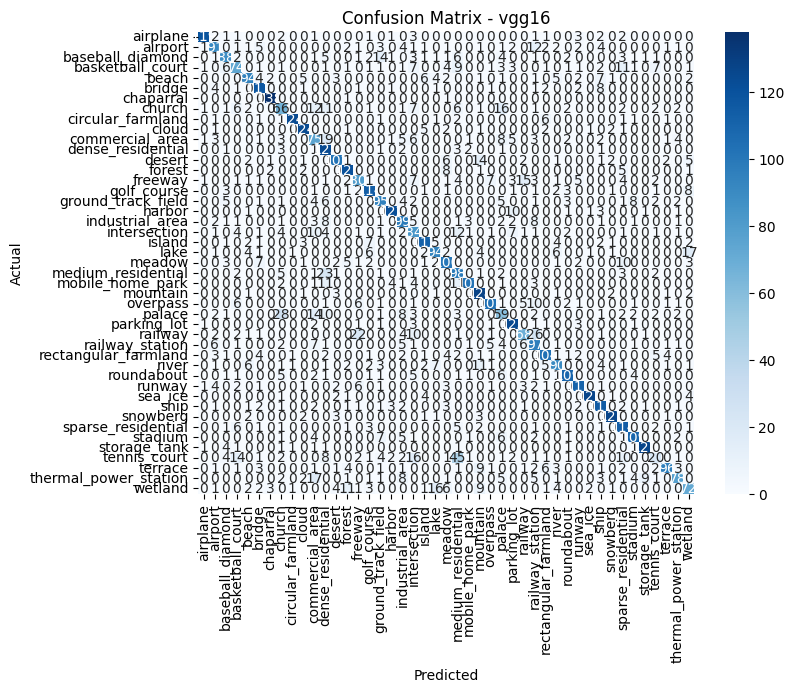

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

===== Training efficientnetb0 =====
Epoch 1/15


2026-01-16 08:13:41.351964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:13:41.495721: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:13:41.842691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:13:41.984156: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:13:42.709790: E external/local_xla/xla/stream_

621/788 ━━━━━━━━━━━━━━━━━━━━ 59s 356ms/step - accuracy: 0.0208 - loss: 3.8230

2026-01-16 08:17:34.211583: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:17:34.351418: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:17:34.672017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:17:34.813094: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:17:35.508729: E external/local_xla/xla/stream_

788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.0207 - loss: 3.8204

2026-01-16 08:19:08.399647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:19:08.542237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:19:08.880585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:19:09.021572: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-16 08:19:09.708981: E external/local_xla/xla/stream_

788/788 ━━━━━━━━━━━━━━━━━━━━ 346s 412ms/step - accuracy: 0.0207 - loss: 3.8204 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 2/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 298s 378ms/step - accuracy: 0.0206 - loss: 3.8070 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 3/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 299s 380ms/step - accuracy: 0.0201 - loss: 3.8070 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 4/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 294s 372ms/step - accuracy: 0.0225 - loss: 3.8069 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 5/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 294s 373ms/step - accuracy: 0.0222 - loss: 3.8070 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 6/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 294s 373ms/step - accuracy: 0.0218 - loss: 3.8069 - val_accuracy: 0.0222 - val_loss: 3.8067


Model saved at /kaggle/working/models/efficientnetb0.h5


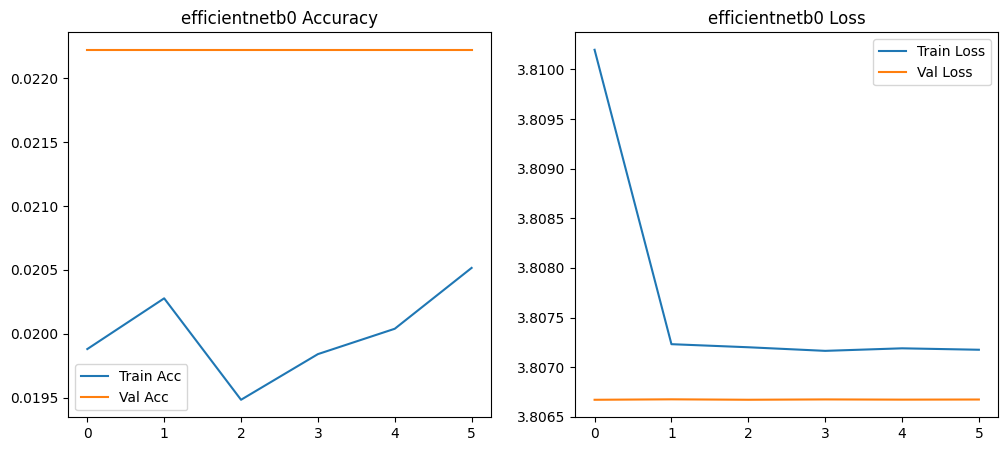

197/197 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step

Classification Report for efficientnetb0
                       precision    recall  f1-score   support

             airplane       0.00      0.00      0.00       140
              airport       0.00      0.00      0.00       140
     baseball_diamond       0.00      0.00      0.00       140
     basketball_court       0.00      0.00      0.00       140
                beach       0.00      0.00      0.00       140
               bridge       0.00      0.00      0.00       140
            chaparral       0.00      0.00      0.00       140
               church       0.00      0.00      0.00       140
    circular_farmland       0.00      0.00      0.00       140
                cloud       0.00      0.00      0.00       140
      commercial_area       0.00      0.00      0.00       140
    dense_residential       0.02      1.00      0.04       140
               desert       0.00      0.00      0.00       140
               forest       0.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


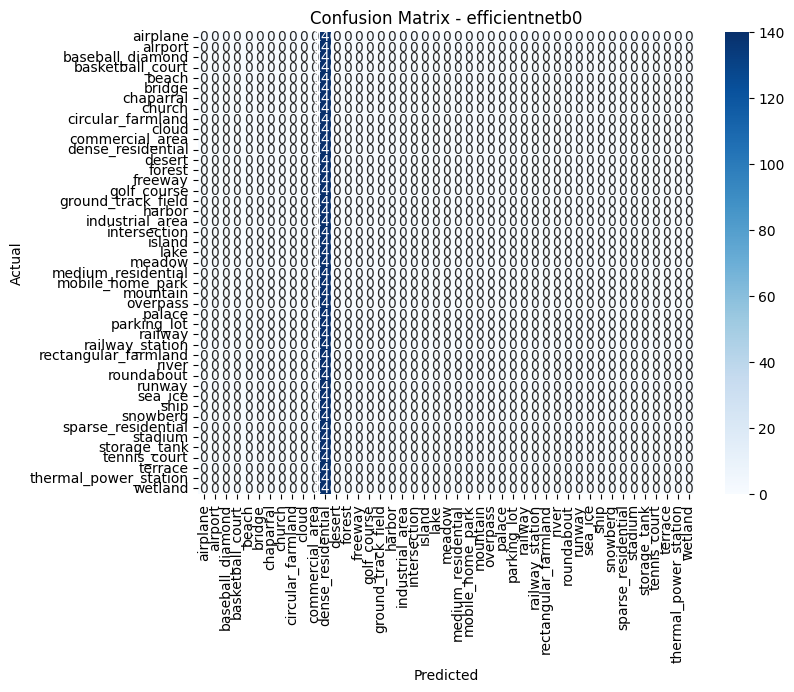

In [19]:
# =====================
# EVALUATION
# =====================

def evaluate_model(model, name):
    val_gen.reset()
    preds = model.predict(val_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_gen.classes

    print(f"\nClassification Report for {name}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =====================
# TRAIN ALL MODELS
# =====================

custom_cnn = train_and_evaluate(build_custom_cnn(), "custom_cnn")

mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
mobilenet_model = train_and_evaluate(build_transfer_model(mobilenet_base), "mobilenetv2")

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg_model = train_and_evaluate(build_transfer_model(vgg_base), "vgg16")

eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
eff_model = train_and_evaluate(build_transfer_model(eff_base), "efficientnetb0")



In [23]:
# =====================
# PREDICTION FUNCTION
# =====================

from tensorflow.keras.preprocessing import image

def predict_image(model_path, img_path):
    model = tf.keras.models.load_model(model_path)

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_arr = image.img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    preds = model.predict(img_arr)
    class_idx = np.argmax(preds)
    confidence = np.max(preds)

    print("Predicted class:", CLASS_NAMES[class_idx])
    print("Confidence:", float(confidence))

# =====================
# EXAMPLE USAGE
# =====================

print("\nTraining complete. Models saved in /kaggle/working/models")



Training complete. Models saved in /kaggle/working/models


In [ ]:
predict_image("Models/mobilenetv2.h5", "ISatelitales/snowberg/snowberg_051.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted class: snowberg
Confidence: 0.9652060866355896


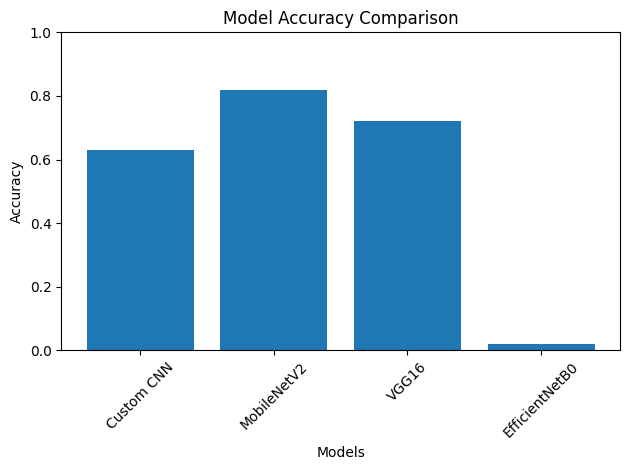

In [2]:
import matplotlib.pyplot as plt

# Model names
models = ["Custom CNN", "MobileNetV2", "VGG16", "EfficientNetB0"]

# Corresponding accuracies
accuracies = [0.63, 0.82, 0.72, 0.02]

# Create bar chart
plt.figure()
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()